In [1]:
from typing import List
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

from ccxt.binance import binance
from ccxt.hyperliquid import hyperliquid
from ccxt.lighter import lighter

from siglab_py.util.market_data_util import fetch_candles
from siglab_py.util.analytic_util import compute_candles_stats

In [2]:
start_date = datetime(2025, 1,1)
end_date = datetime(2025,12,31,0,0,0)
exchange = hyperliquid()
ticker = "BTC/USDC:USDC"
candle_size = "1h"

# Fetch candles

In [3]:
candles = fetch_candles(
                                                start_ts=int(start_date.timestamp()), 
                                                end_ts=int(end_date.timestamp()), 
                                                exchange=exchange, normalized_symbols=[ticker], 
                                                candle_size = candle_size, 
                                                num_candles_limit = 100,
                                                logger = None
                                            )
pd_candles = candles[ticker]

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\market_data_util.py:352: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]


# Compute TA

In [4]:
compute_candles_stats(
            pd_candles=pd_candles,
            boillenger_std_multiples=2,
            sliding_window_how_many_candles=24,
            pypy_compat=False # Slopes calculation? Set pypy_compat to False
        )

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\market_data_util.py:352: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]
c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:592: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pd_candles['aggressive_down_candle_high'] = pd_candles.index.to_series().apply(
c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:597: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

# EMA Slope

In [5]:
selected = pd_candles.iloc[-90:]

In [6]:
selected = selected[['datetime', 'close', 'ema_long_periods', 'ema_long_slope', 'normalized_ema_long_slope']]

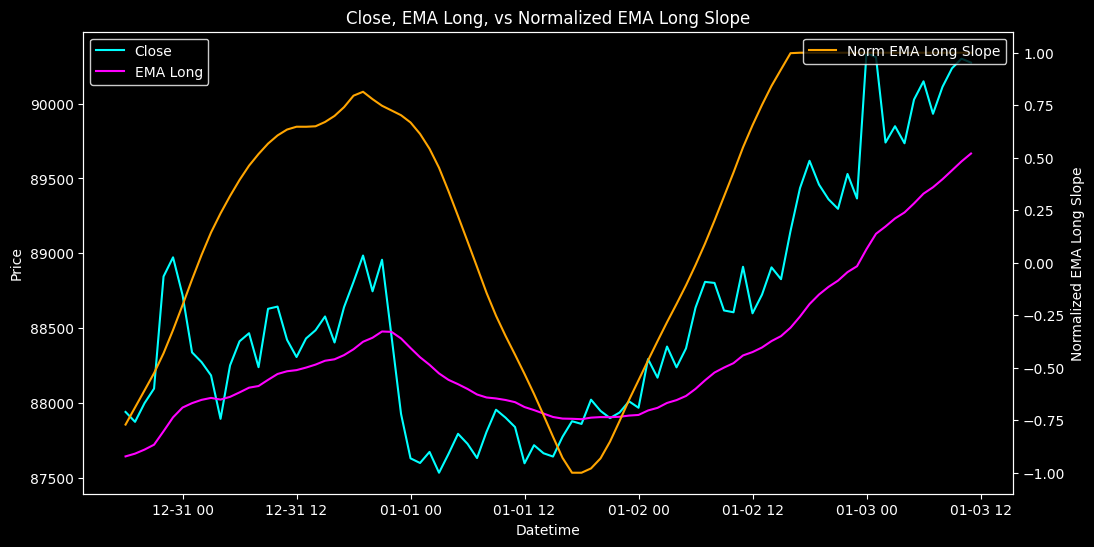

In [7]:
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

ax1.set_xlabel('Datetime', color='white')
ax1.set_ylabel('Price', color='white')
ax1.plot(selected['datetime'], selected['close'], color='cyan', label='Close')
ax1.plot(selected['datetime'], selected['ema_long_periods'], color='magenta', label='EMA Long')
ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', colors='white')
ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

ax2 = ax1.twinx()
ax2.set_ylabel('Normalized EMA Long Slope', color='white')
ax2.plot(selected['datetime'], selected['normalized_ema_long_slope'], color='orange', label='Norm EMA Long Slope')
ax2.tick_params(axis='y', colors='white')
ax2.legend(loc='upper right', facecolor='black', edgecolor='white')

plt.title('Close, EMA Long, vs Normalized EMA Long Slope', color='white')
plt.show()

# Choppiness Index

## SOL

In [8]:
start_date = datetime(2026,1,1)
end_date = datetime(2026,4,12,0,0,0)
exchange = binance()
ticker = "SOL/USDT:USDT"
candle_size = "15m"

In [9]:
sol_candles = fetch_candles(
                                                start_ts=int(start_date.timestamp()), 
                                                end_ts=int(end_date.timestamp()), 
                                                exchange=exchange, normalized_symbols=[ticker], 
                                                candle_size = candle_size, 
                                                num_candles_limit = 100,
                                                logger = None
                                            )
pd_sol_candles = sol_candles[ticker]

In [10]:
compute_candles_stats(
            pd_candles=pd_sol_candles,
            boillenger_std_multiples=2,
            sliding_window_how_many_candles=14,
            pypy_compat=False # Slopes calculation? Set pypy_compat to False
        )

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:592: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pd_candles['aggressive_down_candle_high'] = pd_candles.index.to_series().apply(
c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:597: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pd_candles['aggressive_down_candle_low'] = pd_candles.index.to_series().apply(
c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:634: Perform

In [32]:
selected = pd_sol_candles[['datetime', 'close', 'atr_bps', 'ema_long_periods', 'choppiness_index', 'choppiness_index_up', 'choppiness_index_down', 'ema_choppiness_index', 'ema_choppiness_index_up', 'ema_choppiness_index_down']].iloc[-(4*24 *60):]

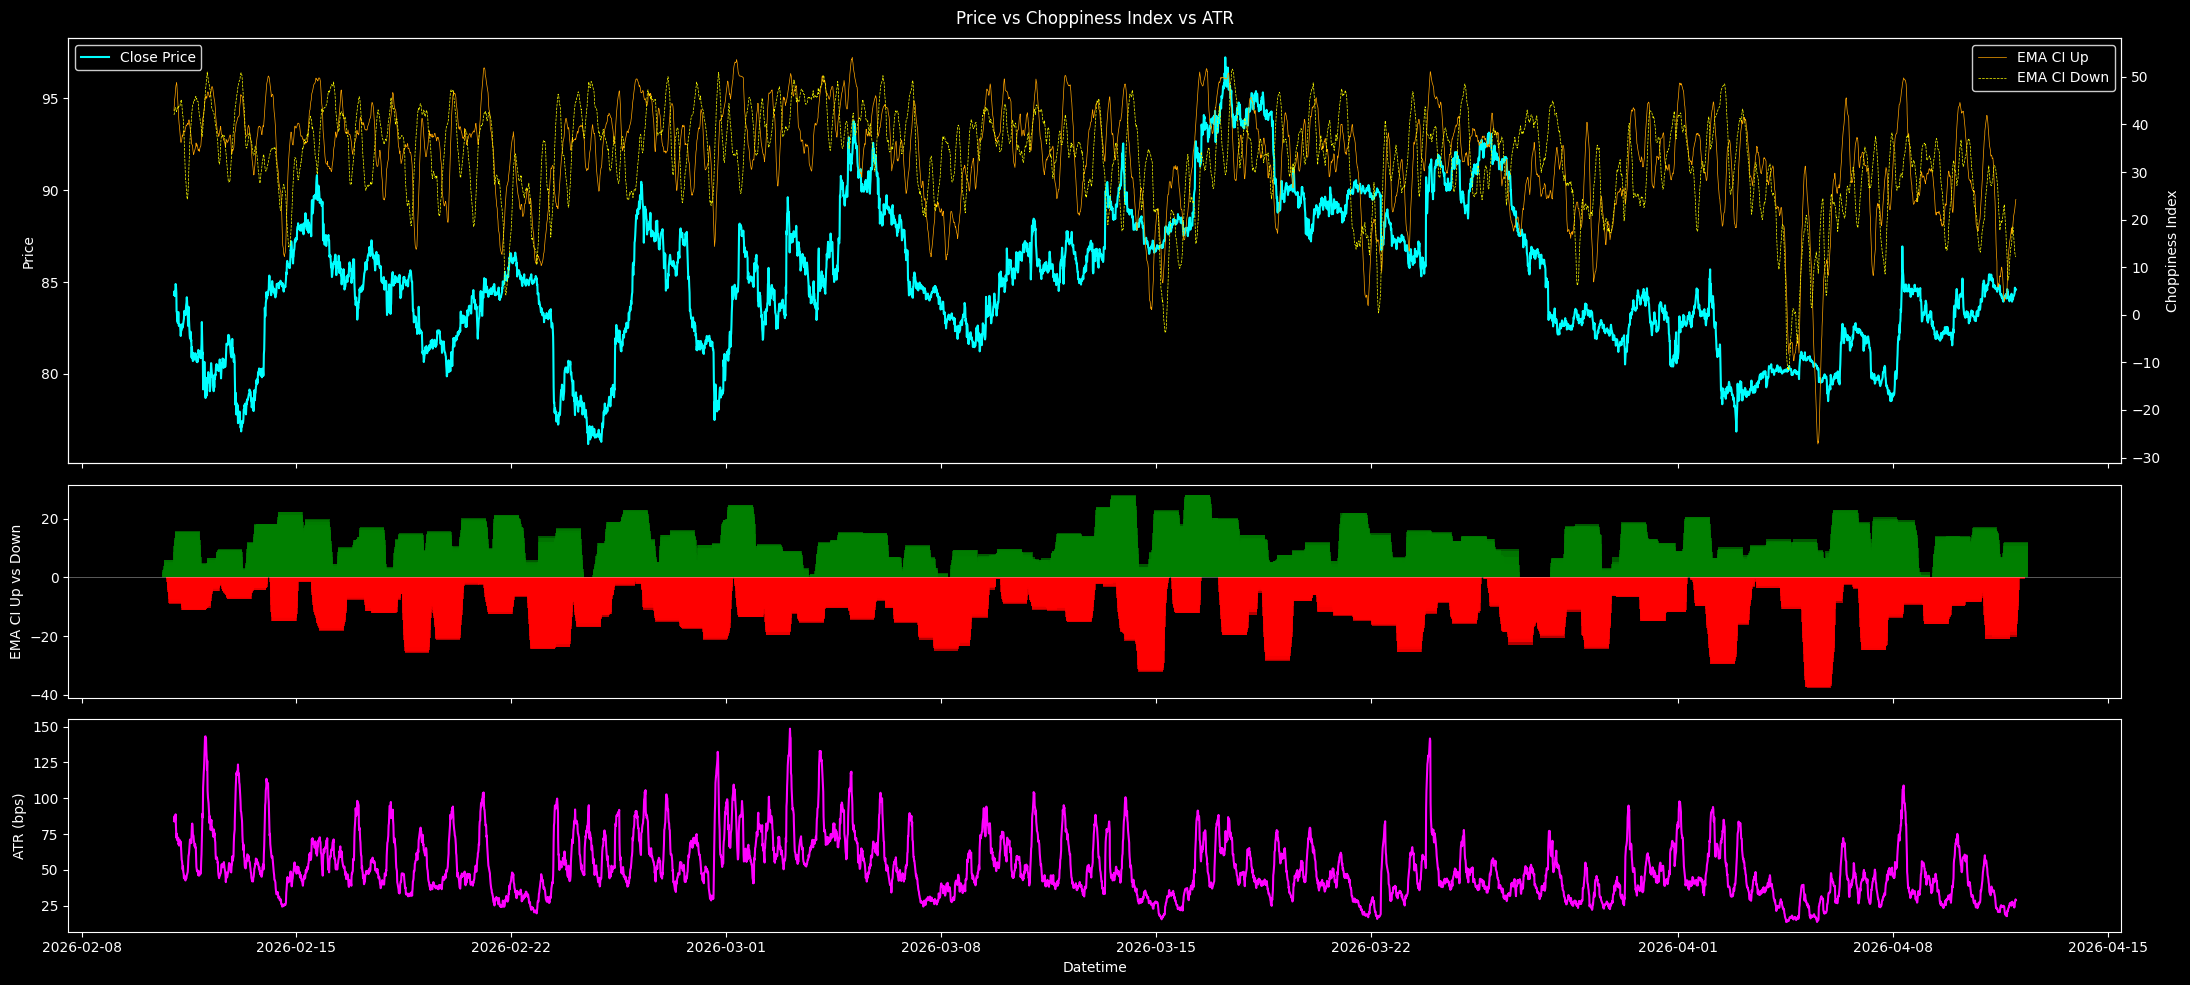

In [ ]:
plt.style.use('dark_background')

fig, (ax_top, ax_mid, ax_bottom) = plt.subplots(
    3, 1,
    figsize=(22, 10),
    facecolor='black',
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1, 1]}
)

ax_top.set_facecolor('black')
ax_top.set_ylabel('Price', color='white')
ax_top.plot(selected['datetime'], selected['close'], color='cyan', label='Close Price')
ax_top.tick_params(axis='y', colors='white')
ax_top.tick_params(axis='x', colors='white')
ax_top.legend(loc='upper left', facecolor='black', edgecolor='white')

ax_top_twin = ax_top.twinx()
ax_top_twin.set_ylabel('Choppiness Index', color='white')
ax_top_twin.plot(
    selected['datetime'], selected['ema_choppiness_index_up'],
    color='orange', label='EMA CI Up', linestyle='-', linewidth=0.5
)
ax_top_twin.plot(
    selected['datetime'], selected['ema_choppiness_index_down'],
    color='yellow', label='EMA CI Down', linestyle='--', linewidth=0.5
)
ax_top_twin.tick_params(axis='y', colors='white')
ax_top_twin.legend(loc='upper right', facecolor='black', edgecolor='white')

diff = selected['ema_choppiness_index_up'] - selected['ema_choppiness_index_down']
colors = ['green' if val >= 0 else 'red' for val in diff]

ax_mid.set_facecolor('black')
ax_mid.bar(selected['datetime'], diff, color=colors, width=0.8, alpha=0.7)
ax_mid.set_ylabel('EMA CI Up vs Down', color='white')
ax_mid.tick_params(axis='y', colors='white')
ax_mid.tick_params(axis='x', colors='white')
ax_mid.axhline(y=0, color='white', linestyle='-', linewidth=0.5, alpha=0.5)

ax_bottom.set_facecolor('black')
ax_bottom.set_ylabel('ATR (bps)', color='white')
ax_bottom.plot(selected['datetime'], selected['atr_bps'], color='magenta', linewidth=1.5)
ax_bottom.tick_params(axis='y', colors='white')
ax_bottom.tick_params(axis='x', colors='white')
ax_bottom.set_xlabel('Datetime', color='white')   # x‑axis label only on the lowest plot

# Overall title
plt.suptitle('Price vs Choppiness Index vs ATR', color='white', y=0.98)
plt.tight_layout()
plt.show()

## XAU

In [13]:
start_date = datetime(2026,1,1)
end_date = datetime(2026,4,12,0,0,0)
exchange = binance()
ticker = "SOL/USDT:USDT"
candle_size = "15m"

In [14]:
xau_candles = fetch_candles(
                                                start_ts=int(start_date.timestamp()), 
                                                end_ts=int(end_date.timestamp()), 
                                                exchange=exchange, normalized_symbols=[ticker], 
                                                candle_size = candle_size, 
                                                num_candles_limit = 100,
                                                logger = None
                                            )
pd_xau_candles = xau_candles[ticker]

In [15]:
compute_candles_stats(
            pd_candles=pd_xau_candles,
            boillenger_std_multiples=2,
            sliding_window_how_many_candles=14,
            pypy_compat=False # Slopes calculation? Set pypy_compat to False
        )

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:592: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pd_candles['aggressive_down_candle_high'] = pd_candles.index.to_series().apply(
c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:597: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pd_candles['aggressive_down_candle_low'] = pd_candles.index.to_series().apply(
c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:634: Perform

In [34]:
selected = pd_xau_candles[['datetime', 'close', 'atr_bps', 'ema_long_periods', 'choppiness_index', 'choppiness_index_up', 'choppiness_index_down', 'ema_choppiness_index', 'ema_choppiness_index_up', 'ema_choppiness_index_down']]

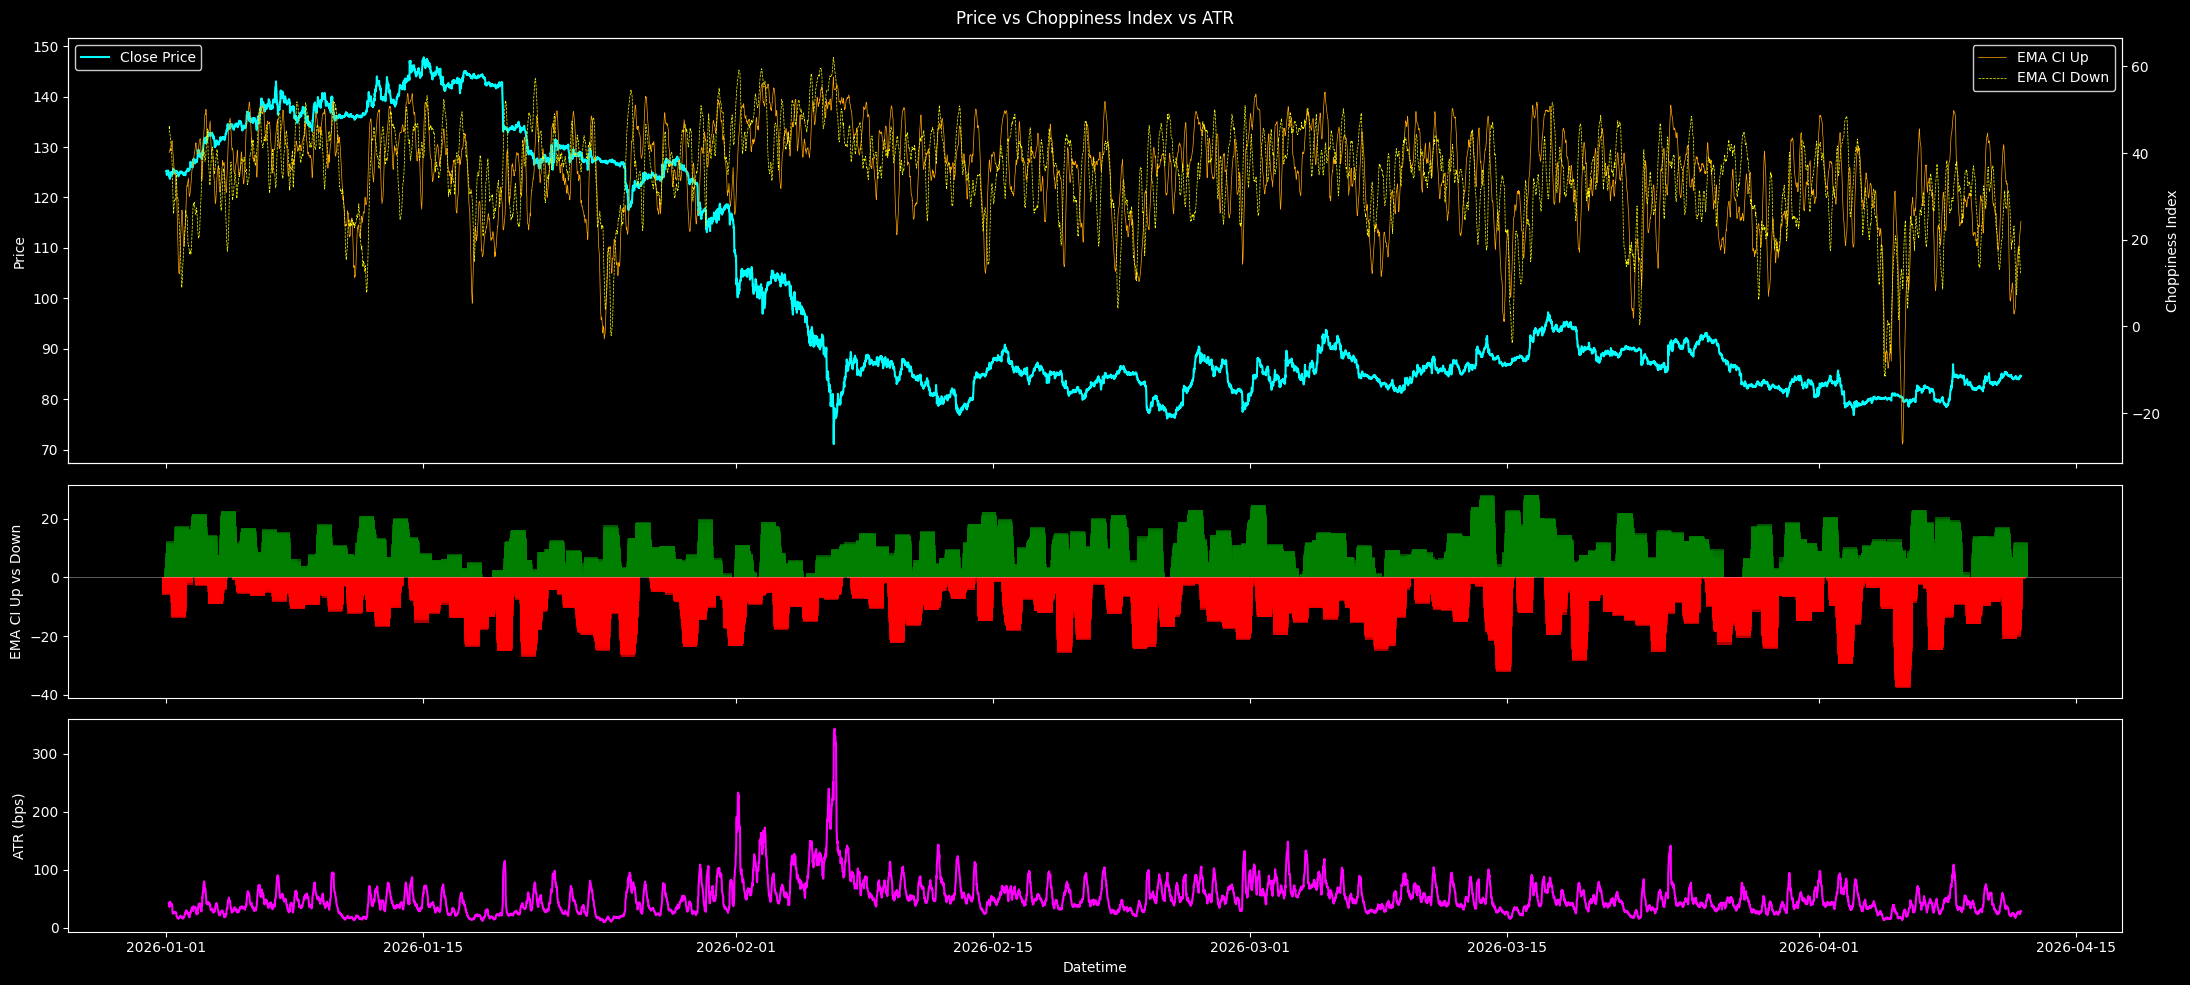

In [35]:
plt.style.use('dark_background')

fig, (ax_top, ax_mid, ax_bottom) = plt.subplots(
    3, 1,
    figsize=(22, 10),
    facecolor='black',
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1, 1]}
)

ax_top.set_facecolor('black')
ax_top.set_ylabel('Price', color='white')
ax_top.plot(selected['datetime'], selected['close'], color='cyan', label='Close Price')
ax_top.tick_params(axis='y', colors='white')
ax_top.tick_params(axis='x', colors='white')
ax_top.legend(loc='upper left', facecolor='black', edgecolor='white')

ax_top_twin = ax_top.twinx()
ax_top_twin.set_ylabel('Choppiness Index', color='white')
ax_top_twin.plot(
    selected['datetime'], selected['ema_choppiness_index_up'],
    color='orange', label='EMA CI Up', linestyle='-', linewidth=0.5
)
ax_top_twin.plot(
    selected['datetime'], selected['ema_choppiness_index_down'],
    color='yellow', label='EMA CI Down', linestyle='--', linewidth=0.5
)
ax_top_twin.tick_params(axis='y', colors='white')
ax_top_twin.legend(loc='upper right', facecolor='black', edgecolor='white')

diff = selected['ema_choppiness_index_up'] - selected['ema_choppiness_index_down']
colors = ['green' if val >= 0 else 'red' for val in diff]

ax_mid.set_facecolor('black')
ax_mid.bar(selected['datetime'], diff, color=colors, width=0.8, alpha=0.7)
ax_mid.set_ylabel('EMA CI Up vs Down', color='white')
ax_mid.tick_params(axis='y', colors='white')
ax_mid.tick_params(axis='x', colors='white')
ax_mid.axhline(y=0, color='white', linestyle='-', linewidth=0.5, alpha=0.5)

ax_bottom.set_facecolor('black')
ax_bottom.set_ylabel('ATR (bps)', color='white')
ax_bottom.plot(selected['datetime'], selected['atr_bps'], color='magenta', linewidth=1.5)
ax_bottom.tick_params(axis='y', colors='white')
ax_bottom.tick_params(axis='x', colors='white')
ax_bottom.set_xlabel('Datetime', color='white')   # x‑axis label only on the lowest plot

plt.suptitle('Price vs Choppiness Index vs ATR', color='white', y=0.98)
plt.tight_layout()
plt.show()